# 04 -- Network Clusters
60-day rolling correlation -> hierarchical clustering -> within-cluster rank.
Saves `network_clusters_monthly.parquet`.

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
warnings.filterwarnings('ignore')

art = pd.read_parquet('../data/processed/panel_artemis_daily.parquet')
uni = pd.read_parquet('../data/processed/universe_monthly.parquet')

art['date'] = pd.to_datetime(art['date'])
uni['date'] = pd.to_datetime(uni['date'])
art = art.sort_values(['symbol', 'date'])

rebalance_dates = sorted(uni['date'].unique())
price_w = art.pivot_table(index='date', columns='symbol', values='price', aggfunc='last')

def last_val(wide, t, cols):
    sub = wide.reindex(columns=cols).loc[:t]
    if len(sub) == 0:
        return pd.Series(np.nan, index=cols)
    return sub.ffill().iloc[-1]

print(f"Rebalance dates: {len(rebalance_dates)}")
print(f"Price wide shape: {price_w.shape}")


Rebalance dates: 48
Price wide shape: (1461, 145)


In [2]:
## Clustering loop
# At each rebalance date t:
#   1. 60-day return correlation matrix (data up to and including t -- no lookahead)
#   2. Ward hierarchical clustering -> cluster labels
#   3. Within-cluster rank by 30d momentum

MIN_OBS_FRAC = 0.50   # symbol must have >50% non-NaN return obs in 60d window
N_CLUSTERS   = 5

records = []

for t in rebalance_dates:
    uni_syms = uni[uni['date'] == t]['symbol'].tolist()
    uni_syms = [s for s in uni_syms if s in price_w.columns]

    # 60-day return window ending at t
    t_60 = t - pd.Timedelta(days=60)
    price_60 = price_w.reindex(columns=uni_syms).loc[t_60:t]
    ret_60   = price_60.pct_change().iloc[1:]

    valid_cols = ret_60.columns[ret_60.notna().mean() > MIN_OBS_FRAC].tolist()

    # 30d momentum for within-cluster rank
    t_30  = t - pd.Timedelta(days=30)
    p_now = last_val(price_w, t,    uni_syms)
    p_30  = last_val(price_w, t_30, uni_syms)
    mom_30 = (p_now / p_30.replace(0, np.nan) - 1)

    if len(valid_cols) < 4:
        for sym in uni_syms:
            records.append({'symbol': sym, 'date': t,
                            'cluster_id': 0, 'cluster_size': len(uni_syms),
                            'within_cluster_rank': 0.5})
        continue

    # Correlation -> distance -> Ward linkage
    ret_filled = ret_60[valid_cols].fillna(0)
    corr       = ret_filled.corr().clip(-1, 1)
    dist_mat   = np.sqrt(0.5 * (1.0 - corr.values))
    np.fill_diagonal(dist_mat, 0.0)
    dist_cond  = squareform(dist_mat, checks=False)

    Z      = linkage(dist_cond, method='ward')
    k      = min(N_CLUSTERS, len(valid_cols) - 1)
    labels = fcluster(Z, k, criterion='maxclust')
    cmap   = dict(zip(valid_cols, labels.tolist()))

    for sym in uni_syms:
        cid = cmap.get(sym, -1)
        if cid == -1:
            records.append({'symbol': sym, 'date': t,
                            'cluster_id': 0, 'cluster_size': 1,
                            'within_cluster_rank': 0.5})
            continue
        cluster_syms = [s for s, c in cmap.items() if c == cid]
        cluster_rets = mom_30.reindex(cluster_syms).dropna()
        sym_ret = mom_30.get(sym, np.nan)
        if pd.isna(sym_ret) or len(cluster_rets) == 0:
            rank = 0.5
        else:
            rank = float((cluster_rets < sym_ret).sum()) / len(cluster_rets)
        records.append({
            'symbol': sym, 'date': t,
            'cluster_id': int(cid), 'cluster_size': len(cluster_syms),
            'within_cluster_rank': rank,
        })

clusters_df = pd.DataFrame(records)
print(f"Clusters output: {clusters_df.shape}")
print("\nCluster size distribution:")
print(clusters_df['cluster_size'].value_counts().sort_index().to_string())
print("\nWithin-cluster rank distribution:")
print(clusters_df['within_cluster_rank'].describe().round(3).to_string())


Clusters output: (2400, 5)

Cluster size distribution:
cluster_size
1      45
2      44
3      63
4      80
5      85
6     102
7      63
8      64
9      90
10     80
11     44
12     24
13     78
14     14
15     60
16     64
17     51
18     54
19     57
20     20
21     42
22     44
23     23
24     24
25     50
26     26
27     81
28     56
29     58
30     30
33    198
34     34
35    140
36     36
37     37
40     80
41     41
42     42
43     86
45     90

Within-cluster rank distribution:
count    2400.000
mean        0.450
std         0.293
min         0.000
25%         0.200
50%         0.455
75%         0.700
max         0.978


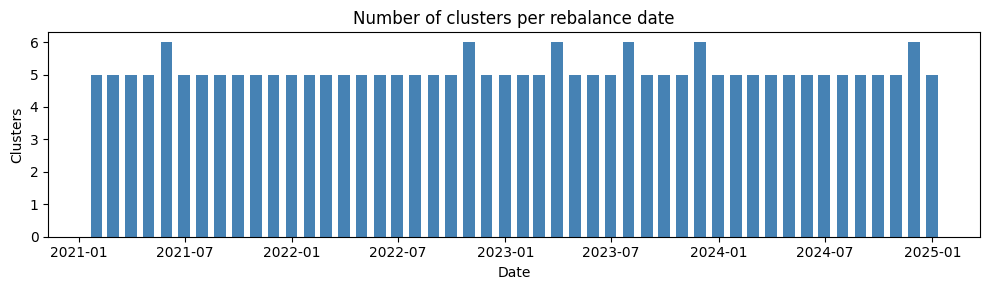

In [3]:
## Plot cluster counts over time
cluster_counts = clusters_df.groupby('date')['cluster_id'].nunique()
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(cluster_counts.index, cluster_counts.values, width=20, color='steelblue')
ax.set_title('Number of clusters per rebalance date')
ax.set_ylabel('Clusters'); ax.set_xlabel('Date')
plt.tight_layout(); plt.show()


In [4]:
out_path = '../data/processed/network_clusters_monthly.parquet'
clusters_df.to_parquet(out_path, index=False)
print(f"Saved: {out_path}  shape={clusters_df.shape}")
print("\n>> Network clusters complete.")


Saved: ../data/processed/network_clusters_monthly.parquet  shape=(2400, 5)

>> Network clusters complete.
